<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/Resume_Screening_(Logistic_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
 from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv"
df=pd.read_csv(path)
df.head(5)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [7]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [8]:
df.isnull().any().any()

np.True_

In [9]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [10]:
df['Certifications'].fillna('No Certification', inplace=True)
df['Certifications'].isnull().sum()

/tmp/ipykernel_2957/67032770.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certifications'].fillna('No Certification', inplace=True)


np.int64(0)

In [11]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [12]:
#print missing value
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)


In [13]:
print(df['Job Role'].unique())

['AI Researcher' 'Data Scientist' 'Cybersecurity Analyst'
 'Software Engineer']


In [14]:
print(df['Education'].unique())

['B.Sc' 'MBA' 'B.Tech' 'PhD' 'M.Tech']


In [15]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100


In [16]:
df.shape

(1000, 11)

In [17]:
df['Recruiter_Decision_Mapped'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
display(df.head())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter_Decision_Mapped
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100,1


In [18]:
df['Recruiter_Decision_Mapped'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
display(df.head())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter_Decision_Mapped
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100,1


In [19]:
X=df.iloc[:,:-1]
print(X)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

In [20]:
Y=df.iloc[:,-1]
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    1
998    1
999    1
Name: Recruiter_Decision_Mapped, Length: 1000, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.7,test_size=0.3,random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()

In [23]:
## Hyper parameter tunning
from sklearn.model_selection import GridSearchCV
parameter={'penalty':['l1','l2','elasticnet'],'C':[1,2,3,4,5,6,10,20,30,40,50],'max_iter':[100,200,300,400], 'solver': ['saga']}

In [24]:
classifier_regression = GridSearchCV(classifier,param_grid=parameter,scoring='accuracy',cv=5, n_jobs=-1)

In [25]:
columns_to_drop = ['Resume_ID', 'Name', 'Recruiter Decision']
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print("X_train columns after dropping:", X_train.columns.tolist())
print("X_test columns after dropping:", X_test.columns.tolist())

X_train columns after dropping: ['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_test columns after dropping: ['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']


In [26]:
categorical_cols = ['Skills', 'Education', 'Certifications', 'Job Role']

# Concatenate train and test for consistent encoding
X_combined = pd.concat([X_train, X_test], axis=0)
X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_cols, drop_first=True)

# Split back into X_train and X_test
X_train_encoded = X_combined_encoded.iloc[:len(X_train)]
X_test_encoded = X_combined_encoded.iloc[len(X_train):]

# Display the first few rows of the encoded training data
display(X_train_encoded.head())

,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React","Skills_C++, React","Skills_C++, React, Java",...,Education_B.Tech,Education_M.Tech,Education_MBA,Education_PhD,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_No Certification,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
541,6,89840,2,95,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False
440,9,105724,10,100,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
482,10,76012,1,100,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True
422,8,108667,0,100,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
778,10,58090,4,100,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,True,False


In [27]:
classifier_regression.fit(X_train_encoded,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
220 fits failed out of a total of 660.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
220 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1203, in fit
    raise ValueError("l

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50],
                         'max_iter': [100, 200, 300, 400],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

In [28]:
print(classifier_regression.best_params_)

{'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


In [29]:
print(classifier_regression.best_score_)

0.8228571428571427


In [30]:
Y_pred=classifier_regression.predict(X_test_encoded)

In [31]:
from sklearn.metrics import accuracy_score, classification_report

In [32]:
score= accuracy_score(Y_pred,Y_test)
print(score)

0.7866666666666666


In [33]:
print(classification_report(Y_pred,Y_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.79      0.88       300

    accuracy                           0.79       300
   macro avg       0.50      0.39      0.44       300
weighted avg       1.00      0.79      0.88       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


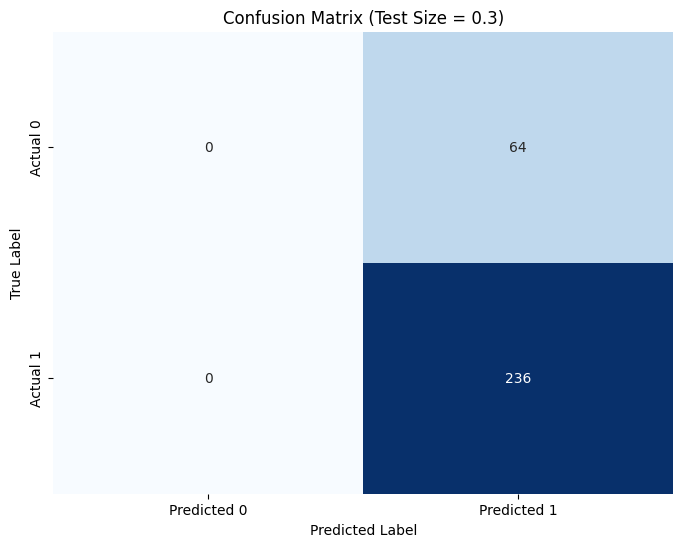

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_0_3 = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_0_3, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Size = 0.3)')
plt.show()

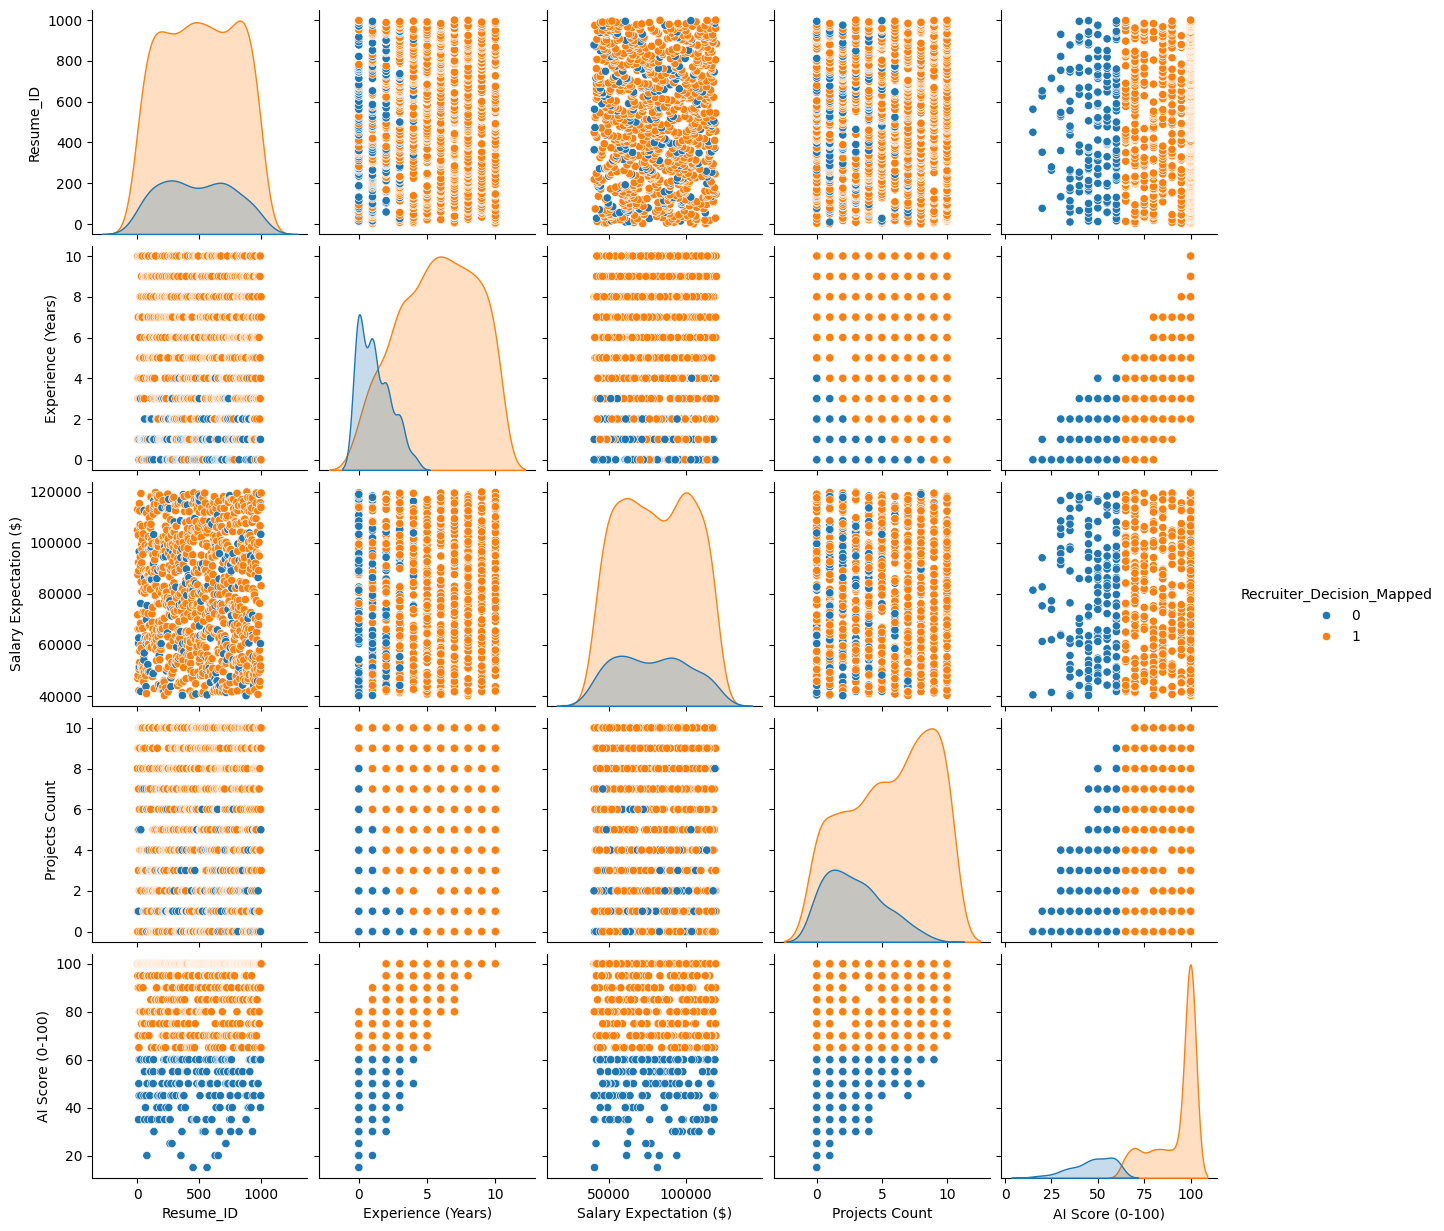

In [35]:
sns.pairplot(df, hue='Recruiter_Decision_Mapped')

In [36]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()
print(correlation_matrix)

                           Resume_ID  Experience (Years)  \
Resume_ID                   1.000000            0.021094   
Experience (Years)          0.021094            1.000000   
Salary Expectation ($)      0.001090            0.034814   
Projects Count              0.024475           -0.066596   
AI Score (0-100)            0.029713            0.777042   
Recruiter_Decision_Mapped   0.034135            0.576235   

                           Salary Expectation ($)  Projects Count  \
Resume_ID                                0.001090        0.024475   
Experience (Years)                       0.034814       -0.066596   
Salary Expectation ($)                   1.000000        0.021759   
Projects Count                           0.021759        1.000000   
AI Score (0-100)                         0.033354        0.358666   
Recruiter_Decision_Mapped                0.044073        0.331249   

                           AI Score (0-100)  Recruiter_Decision_Mapped  
Resume_ID             

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8,test_size=0.2 ,random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()

In [39]:
## Hyper parameter tunning
from sklearn.model_selection import GridSearchCV
parameter={'penalty':['l1','l2','elasticnet'],'C':[1,2,3,4,5,6,10,20,30,40,50],'max_iter':[100,200,300,400], 'solver': ['saga']}

In [40]:
classifier_regression = GridSearchCV(classifier,param_grid=parameter,scoring='accuracy',cv=5, n_jobs=-1)

In [41]:
columns_to_drop = ['Resume_ID', 'Name', 'Recruiter Decision']
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print("X_train columns after dropping:", X_train.columns.tolist())
print("X_test columns after dropping:", X_test.columns.tolist())

X_train columns after dropping: ['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_test columns after dropping: ['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']


In [42]:
categorical_cols = ['Skills', 'Education', 'Certifications', 'Job Role']

# Concatenate train and test for consistent encoding
X_combined = pd.concat([X_train, X_test], axis=0)
X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_cols, drop_first=True)

# Split back into X_train and X_test
X_train_encoded = X_combined_encoded.iloc[:len(X_train)]
X_test_encoded = X_combined_encoded.iloc[len(X_train):]

# Display the first few rows of the encoded training data
display(X_train_encoded.head())

,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React","Skills_C++, React","Skills_C++, React, Java",...,Education_B.Tech,Education_M.Tech,Education_MBA,Education_PhD,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_No Certification,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
29,10,59926,4,100,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
535,4,108770,10,100,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
695,3,118062,8,100,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,False,False
557,7,99741,0,95,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
836,9,91723,8,100,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False


In [43]:
classifier_regression.fit(X_train_encoded,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
220 fits failed out of a total of 660.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
220 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1203, in fit
    raise ValueError("l

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50],
                         'max_iter': [100, 200, 300, 400],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

In [44]:
print(classifier_regression.best_params_)

{'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


In [45]:
print(classifier_regression.best_score_)

0.8225


In [46]:
Y_pred=classifier_regression.predict(X_test_encoded)

In [47]:
from sklearn.metrics import accuracy_score, classification_report

In [48]:
score= accuracy_score(Y_pred,Y_test)
print(score)

0.77


In [49]:
print(classification_report(Y_pred,Y_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.77      0.87       200

    accuracy                           0.77       200
   macro avg       0.50      0.39      0.44       200
weighted avg       1.00      0.77      0.87       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


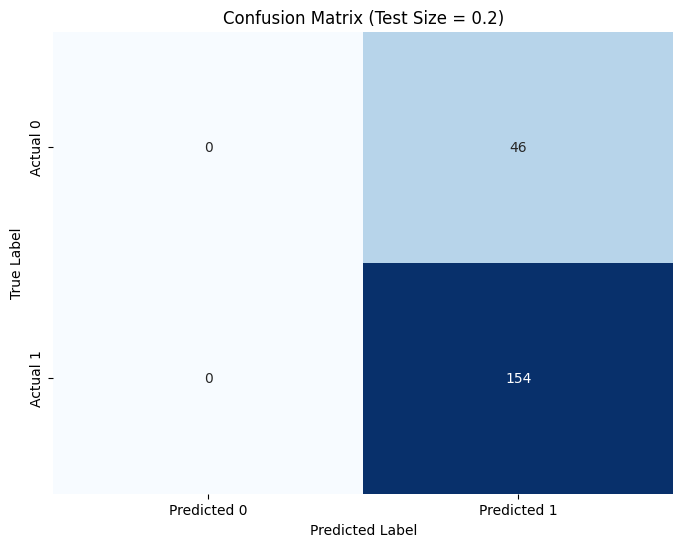

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming Y_test and Y_pred from the 0.2 split are the last ones assigned
# Re-running the prediciton based on the last train/test split (0.2)
# Y_pred for 0.2 is available from cell 2sKbu6IzOUt_
# Y_test for 0.2 is available from cell oL30mlafMjFL

cm_0_2 = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_0_2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Size = 0.2)')
plt.show()